# Which branch should Meera open first to reach the 15 percent plan, and why not the others?

**Week 1, Monday, chapter 5 of 6.** Meera has a tree with every branch measured, and marketing
has proposed moving one branch, customers, for Rs 12 crore. Before she signs, she wants to know
which branch to open first, and why not the others.

**Who needs the answer.** Meera decides where the money goes. The marketing lead owns
acquisition, and the head of Retail-Plus owns the members most likely to come back. The
Rs 12 crore placed on a branch that was never short, or a plan sized by adding lifts that
multiply, spends the budget on the wrong lever.

**The questions on the way.**

1. Which orders is the 15 percent plan sized on, and how many rupees short are they?
2. What would each branch have to do alone to reach the plan?
3. Which branch has evidence behind it?
4. What goes wrong when two 10 percent lifts are called 20 percent?
5. Does adding the lift piece by piece land on the same total?
6. What would switch the call from frequency to acquisition?

The metric at stake is revenue growth against the 15 percent plan, and what each branch alone
would have to do to reach it. Retailers pay to move frequency directly: Flipkart launched
Flipkart Black at Rs 1,499 a year in 2025, evolving it from its VIP programme (Flipkart Stories,
12 September 2025), and Amazon offers Prime in India from Rs 399 to Rs 1,499 a year (About
Amazon India). A membership is a bet on the frequency branch, placed by companies that could have
spent the same money on acquisition. Sections 2 and 5 of the retail dossier,
`study-notes/C2_W01_D01_domain_retail_STUDENT.md`, cover Retail-Plus, the paid tier, and the
acquisition payback.

Chapter 4 settled the typical order: the median is Rs 2,205, and the booked mean of Rs 18,160
sits about eight times above it, so a plan is priced on the customers it targets, with the
median quoted as the typical order. The tree reads 23 customers, 1.30 orders each, 16 of them
bought once, and Rs 5,44,810 booked on 30 orders.

> **Kavya's review.** Pick the branch the evidence points at and the one that costs least to
> test. Then say what would make you pick another.

**Setup.** The first cell finds the shared helper, loads the 30 orders from `../data/`, applies
chapter 1's `int()` fix, and rebuilds the booked tree: customers by id, orders per customer and
average order value (AOV).

In [1]:
import sys, pathlib
here = pathlib.Path.cwd()
for parent in [here, *here.parents]:
    if (parent / "scripts" / "c2kit.py").exists():
        sys.path.insert(0, str(parent / "scripts")); break
import c2kit as kit

ORDERS = kit.load_records()

for order in ORDERS:
    order["amount"] = int(order["amount"])     # chapter 1's fix for an amount stored as text
revenue = sum(o["amount"] for o in ORDERS)
counts = {}
for order in ORDERS:
    counts[order["customer_id"]] = counts.get(order["customer_id"], 0) + 1
customers, orders = len(counts), len(ORDERS)
per_customer, aov = orders / customers, revenue / orders
once = sum(1 for c in counts.values() if c == 1)
print(f"booked: {kit.rupees(revenue)} from {customers} customers, {per_customer:.2f} orders each, about {kit.rupees(round(aov))} an order")

booked: Rs 5,44,810 from 23 customers, 1.30 orders each, about Rs 18,160 an order


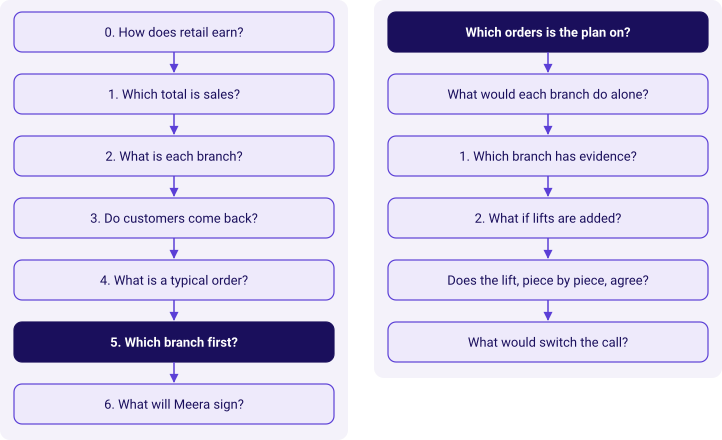

In [2]:
kit.side_by_side(
    kit.vflow(['0. How does retail earn?', '1. Which total is sales?', '2. What is each branch?', '3. Do customers come back?', '4. What is a typical order?', '5. Which branch first?', '6. What will Meera sign?'], lit=5, show=False),
    kit.vflow(['Which orders is the plan on?', 'What would each branch do alone?', '1. Which branch has evidence?', '2. What if lifts are added?', 'Does the lift, piece by piece, agree?', 'What would switch the call?'], lit=0, show=False),
)

## Which orders is the 15 percent plan sized on, and how many rupees short are they?

Meera's growth plan concerns Kalpa's three consumer segments, Retail-Core, Retail-Plus and
Student, since those are the customers a retention offer or an acquisition campaign reaches.
The consumer view keeps the orders whose segment is one of those three, and the plan is sized on
it: 15 percent more than the consumer view booked in the quarter.

**Predict before you run.** How many more rupees does the plan ask of the consumer view?

- a) About Rs 81,700, 15 percent of all booked sales.
- b) About Rs 9,700.
- c) About Rs 64,800.
- d) About Rs 1,500.

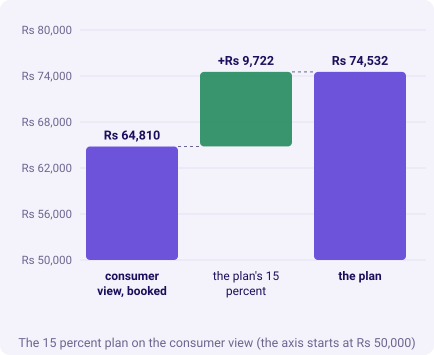

consumer view booked Rs 64,810; the plan Rs 74,532, Rs 9,722 more


In [3]:
CONSUMER = ("Retail-Core", "Retail-Plus", "Student")          # the segments Meera's plan concerns
consumer = [o for o in ORDERS if o["segment"] in CONSUMER]
c_rev = sum(o["amount"] for o in consumer)
plan = c_rev * 1.15
kit.bridge(("consumer view, booked", c_rev), [("the plan's 15 percent", round(plan - c_rev))],
           end_label="the plan", lo=50000,
           title="The 15 percent plan on the consumer view (the axis starts at Rs 50,000)")
print(f"consumer view booked {kit.rupees(c_rev)}; the plan {kit.rupees(int(plan + 0.5))}, "
      f"{kit.rupees(round(plan - c_rev))} more")
kit.check("the consumer view keeps only the three consumer segments",
          {o["segment"] for o in consumer} == set(CONSUMER))
kit.check("the consumer view booked Rs 64,810", c_rev == 64810, kit.rupees(c_rev))
kit.check("the plan asks Rs 9,722 more of it", round(plan - c_rev) == 9722)

**What happened.** The answer is b: the consumer view booked Rs 64,810 in the quarter, so the
plan is about Rs 74,532, Rs 9,722 more.

**Your turn.** How many orders does the consumer view keep? Type this line into the empty cell
below and run it:

```python
print(len(consumer), "orders in the consumer view, of", len(ORDERS))
```

## What would each branch have to do alone to reach the plan?

Any one branch could carry the plan alone, and each asks something different of different
people, set out below with each branch's ask sized in rupees and percentages.

| Option | The branch moved alone | Who has to act | Evidence in this file |
|---|---|---|---|
| A. Acquisition | customers | People Kalpa has never met have to start buying. | There is none, since one window cannot show customers falling. |
| B. Frequency | orders per customer | Customers already on file have to buy again. | Some customers already came back in the quarter. |
| C. Order value | rupees per order | Every shopper has to spend more on every basket. | Items and prices are not in this file. |
| D. Price | price per item | Every shopper has to pay more, and nobody may leave. | There is none, and nothing may sell above its printed maximum retail price. |

**Predict before you run.** Once each branch is sized, which one does the evidence in this file
favour?

- a) Customers: 15 percent more customers who buy like today's.
- b) Frequency: 15 percent more orders from today's customers.
- c) Order value: Rs 335 more on every order.
- d) Price: every price 15 percent higher, with nobody leaving.

option: the branch moved alone,the plan needs,in rupees and percentages,evidence in this file
"A. acquisition, customers",15 percent more customers,"Rs 9,722 of orders from people Kalpa has never met",none: one window cannot show customers falling
"B. frequency, orders per customer",15 percent more orders from the same customers,about three in ten of the one-time buyers returning once,7 customers already came back
C. order value,"Rs 2,235 to Rs 2,570",Rs 335 more on every order,items and prices are not in this file
D. price,15 percent higher prices,"every price up, with nobody leaving","none, and nothing may sell above its printed maximum retail price"


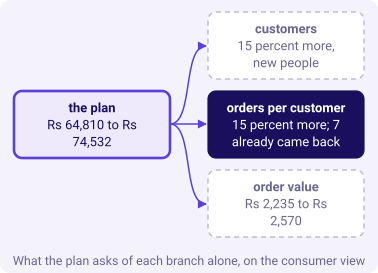

In [4]:
c_counts = {}
for o in consumer:
    c_counts[o["customer_id"]] = c_counts.get(o["customer_id"], 0) + 1
c_cust, c_orders = len(c_counts), len(consumer)
c_once = sum(1 for c in c_counts.values() if c == 1)
c_per, c_aov = c_orders / c_cust, c_rev / c_orders
need = {"customers": c_cust * 1.15, "orders": c_orders * 1.15, "aov": c_aov * 1.15}
returning = (need["orders"] - c_orders) / c_once       # share of one-time buyers who must return once
in_ten = ["none", "one", "two", "three", "four", "five", "six", "seven", "eight", "nine", "ten"]
kit.table(["option: the branch moved alone", "the plan needs", "in rupees and percentages", "evidence in this file"],
          [("A. acquisition, customers", "15 percent more customers",
            f"{kit.rupees(round(plan - c_rev))} of orders from people Kalpa has never met",
            "none: one window cannot show customers falling"),
           ("B. frequency, orders per customer", "15 percent more orders from the same customers",
            f"about {in_ten[round(returning * 10)]} in ten of the one-time buyers returning once",
            f"{c_cust - c_once} customers already came back"),
           ("C. order value", f"{kit.rupees(round(c_aov))} to {kit.rupees(round(need['aov']))}",
            f"{kit.rupees(round(need['aov'] - c_aov))} more on every order", "items and prices are not in this file"),
           ("D. price", "15 percent higher prices", "every price up, with nobody leaving",
            "none, and nothing may sell above its printed maximum retail price")],
          caption=f"The 15 percent plan on the consumer view: {kit.rupees(c_rev)} to {kit.rupees(int(plan + 0.5))}")
kit.driver_tree({"label": "the plan", "note": f"{kit.rupees(c_rev)} to {kit.rupees(int(plan + 0.5))}",
                 "kind": "known", "children": [
    {"label": "customers", "note": "15 percent more, new people", "kind": "unknown"},
    {"label": "orders per customer", "note": f"15 percent more; {c_cust - c_once} already came back", "kind": "lit"},
    {"label": "order value", "note": f"{kit.rupees(round(c_aov))} to {kit.rupees(round(need['aov']))}", "kind": "unknown"}]},
    title="What the plan asks of each branch alone, on the consumer view")

In [5]:
kit.check("customers alone reach the plan through the tree", abs(need["customers"] * c_per * c_aov - plan) < 1)
kit.check("orders alone reach the plan through the tree", abs(need["orders"] * c_aov - plan) < 1)
kit.check("order value alone reaches the plan through the tree", abs(c_orders * need["aov"] - plan) < 1)

**What happened.** The answer is b. Every branch alone has to rise 15 percent, so what separates
them is who is asked and what the file shows. Acquisition has to find 15 percent more customers
Kalpa has never met. Frequency asks about three in ten of the consumer one-time buyers to come
back once, at the consumer view's mean order of Rs 2,235, and 7 customers already did. Order
value needs Rs 335 more on every order and price needs every price 15 percent higher with nobody
leaving, and the file holds neither the items nor the prices that would show how.

**The best-fit call.** B, frequency first: the customers exist, the file shows some of them
return, and a retention test costs a reminder or an offer to people already on the list, where
acquisition pays marketing to find new ones. **What would change it:** a second quarter showing
customers falling while frequency held, or a retained order costing more than a new customer;
the last section says which.

## 1. Which branch has evidence behind it?

The file's evidence for a branch is customers already doing what the branch asks. For frequency
that is customers who bought more than once in the quarter; for acquisition it would be
customers falling from one quarter to the next, which one quarter cannot show.

**Predict before you run.** How many of the 23 customers bought exactly once?

- a) 7.
- b) 23.
- c) 16.
- d) 0.

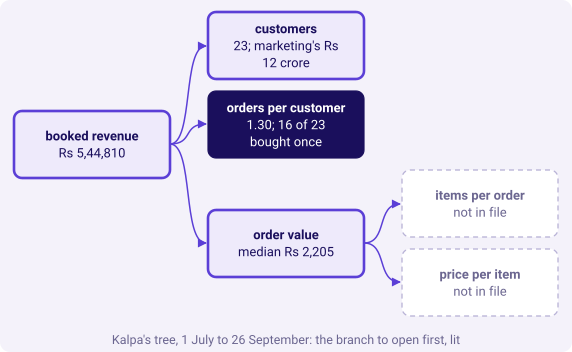

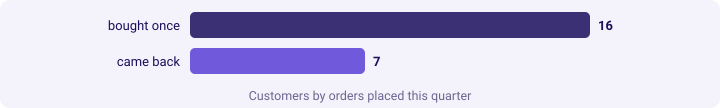

In [6]:
kit.driver_tree({"label": "booked revenue", "note": kit.rupees(revenue), "kind": "known", "children": [
    {"label": "customers", "note": f"{customers}; marketing's Rs 12 crore", "kind": "known"},
    {"label": "orders per customer", "note": f"{per_customer:.2f}; {once} of {customers} bought once", "kind": "lit"},
    {"label": "order value", "note": "median Rs 2,205", "kind": "known", "children": [
        {"label": "items per order", "note": "not in file", "kind": "unknown"},
        {"label": "price per item", "note": "not in file", "kind": "unknown"}]}]},
    title="Kalpa's tree, 1 July to 26 September: the branch to open first, lit")
kit.bars([("bought once", once), ("came back", customers - once)], lit=(0,),
         title="Customers by orders placed this quarter")
kit.check("16 of 23 customers bought once", once == 16)
kit.check("every customer either bought once or came back", once + (customers - once) == 23)

**What happened.** The answer is c: 16 of the 23 customers bought once and 7 came back, so
frequency is the branch with evidence behind it. Its customers exist, some already return, and
the 16 are one order away from moving it.

## 2. What goes wrong when two 10 percent lifts are called 20 percent?

The marketing lead answers the frequency case with a bigger plan: "Fund acquisition and a
retention programme together. A 10 percent lift in customers and a 10 percent lift in orders per
customer make 20 percent growth, well over the 15 percent plan." The rupees below stay on the
consumer view, the base the plan is sized on.

**Predict before you run.** What do the two lifts really make?

- a) 20 percent, as the slide says.
- b) 21 percent.
- c) 10 percent, since the lifts overlap.
- d) 11 percent.

**The plausible wrong answer.**

In [7]:
added = c_rev * (1 + 0.10 + 0.10)                     # the consumer view, as the plan is sized
print(f"Consumer revenue after both lifts: {kit.rupees(round(added))}, growth 20 percent")

Consumer revenue after both lifts: Rs 77,772, growth 20 percent


**Why it is wrong.** The branches multiply, so the lifts multiply: the second lift applies to a
customer base that is already 10 percent larger. Adding them drops the lift on the lift, and at
bigger or more numerous lifts the gap grows until a budget sized by addition misses its target.
The check recomputes revenue leaf by leaf through the tree.

through the tree: Rs 78,420, growth 21%; the slide's figure Rs 77,772, short by Rs 648


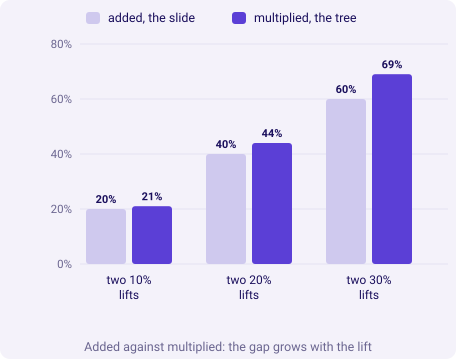

In [8]:
through_tree = (c_cust * 1.10) * (c_per * 1.10) * c_aov
print(f"through the tree: {kit.rupees(round(through_tree))}, growth {through_tree / c_rev - 1:.0%}; "
      f"the slide's figure {kit.rupees(round(added))}, short by {kit.rupees(round(through_tree - added))}")
lifts = [0.10, 0.20, 0.30]
kit.columns([f"two {int(l * 100)}% lifts" for l in lifts],
            [("added, the slide", [2 * l * 100 for l in lifts]),
             ("multiplied, the tree", [((1 + l) ** 2 - 1) * 100 for l in lifts])],
            fmt=lambda v: f"{v:.0f}%", title="Added against multiplied: the gap grows with the lift")
kit.check("through the tree, two 10 percent lifts make 21 percent", round(through_tree / c_rev - 1, 2) == 0.21)
kit.check("the added figure is Rs 77,772", round(added) == 77772)
kit.check("the tree's figure is Rs 78,420", round(through_tree) == 78420)

**What happened.** The answer is b: the two lifts make 21 percent, Rs 78,420, which is Rs 648
above the slide's Rs 77,772. At 10 percent the gap is small; two 30 percent lifts make 69
percent where the slide would say 60. The same rule prices a discount: 15 percent off with 10
percent more orders is 0.85 x 1.10 = 0.935, a 6.5 percent fall that addition would call a 5
percent fall.

## Does adding the lift piece by piece land on the same total?

Revenue after both lifts is the base, plus the customer lift, plus the frequency lift, plus the
lift on the lift, which is 1 percent of the base. A bridge built from those four parts must land
where the multiplication did.

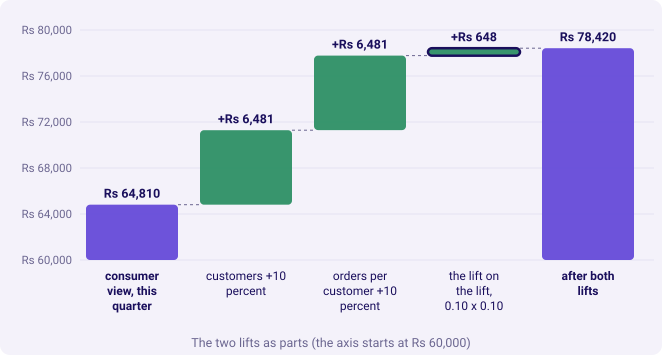

In [9]:
parts = [("customers +10 percent", c_rev * 0.10), ("orders per customer +10 percent", c_rev * 0.10),
         ("the lift on the lift, 0.10 x 0.10", c_rev * 0.01)]
kit.bridge(("consumer view, this quarter", c_rev), [(n, round(v)) for n, v in parts],
           end_label="after both lifts", lit=(2,), lo=60000,
           title="The two lifts as parts (the axis starts at Rs 60,000)")
kit.check("the parts land on the multiplied total", abs(c_rev + sum(v for _, v in parts) - through_tree) < 1e-6)

**What happened.** It does: Rs 64,810, plus Rs 6,481 for customers, plus Rs 6,481 for
frequency, plus Rs 648 for the lift on the lift, lands on Rs 78,420, where the multiplication
did.

**When to switch.** Multiply the factors when you need the total; build the parts when someone
asks where the extra came from, since the bridge shows the lift on the lift as its own bar. The
parts route is the one to bring to marketing.

> **Kavya's review.** Recompute through the tree anything someone adds up. Then tell Meera the
> branch the evidence points at, frequency, and that the lifts multiply whichever she funds.

### How would you answer an interviewer who asks which branch to fund first?

**[D] Marketing wants budget for acquisition; what would you check before agreeing it is the
right branch, and how would you say no?** "I would count customers by id and see how many came
back, price what a new customer brings on the mean order of the segments the plan targets, and
ask for the quarter before this one to see whether customers fell. On Kalpa's quarter
16 of 23 bought once and 7 came back, and the consumer view's mean order is Rs 2,235 against a
booked mean of Rs 18,160. The no is a no for now, with a date: frequency is the cheaper branch
to test, and if Tuesday's two quarters show customers fell, acquisition goes first."

**[F] A 10 percent lift in customers and a 10 percent lift in frequency make 20 percent growth;
what is the right number, and when does it matter?** "The right number is 21 percent, because
branches multiply: 1.10 x 1.10 = 1.21. It matters when the lifts are large or many: two 30 percent lifts make 69
percent where addition says 60, and a target sized by addition is missed by the difference."

**[D] Which of four branches would you open first for a retailer, and what would make you
switch?** "I open the one the evidence says is short and that costs least to test. Here that is
frequency: the customers exist and a third already came back. I would switch to acquisition if a
second window showed customers falling with frequency steady, or if retaining an order cost more
than acquiring a customer."

### How far does a 15 percent discount have to lift orders to break even?

A 15 percent discount needs orders up 1 / 0.85 less one, about 17.6 percent, just to hold
revenue, and more to hold margin.

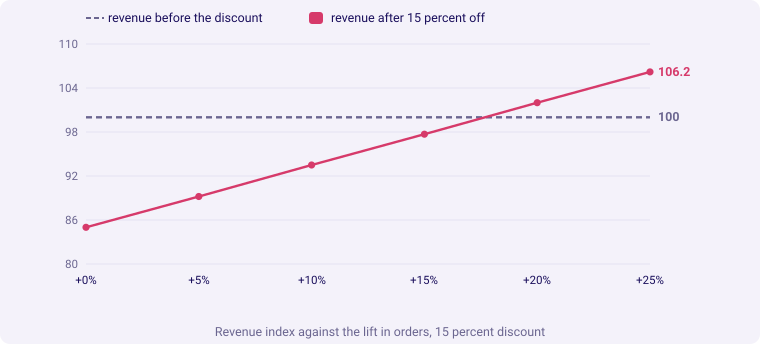

In [10]:
lift_axis = [0, 5, 10, 15, 20, 25]
kit.line([f"+{l}%" for l in lift_axis],
         [("revenue before the discount", [100] * 6, "plan"),
          ("revenue after 15 percent off", [round(85 * (1 + l / 100), 1) for l in lift_axis], "bad")],
         fmt=lambda v: f"{v:g}", lo=80, title="Revenue index against the lift in orders, 15 percent discount")
kit.check("the break-even lift is about 17.6 percent", round((1 / 0.85 - 1) * 100, 1) == 17.6)

## What would switch the call from frequency to acquisition?

Two facts would move the call to acquisition: Tuesday's second quarter showing customers falling
while frequency held, or a retained order costing more than a new customer. Until one of them
arrives, Meera opens frequency first.

- Which orders is the plan sized on? It is sized on the consumer view, which booked Rs 64,810,
  so the plan is about Rs 74,532, Rs 9,722 more.
- What would each branch have to do alone? Each would have to rise 15 percent: 15 percent more
  customers, 15 percent more orders from the same customers, Rs 335 more per order, or prices 15
  percent higher.
- Which branch has evidence behind it? Frequency has it, since 16 of 23 customers bought once
  and 7 came back.
- What goes wrong when two lifts are added? The slide's Rs 77,772 (20 percent) falls Rs 648
  short of the tree's Rs 78,420 (21 percent).
- Does the lift, piece by piece, land on the same total? It does, on Rs 78,420.

In [11]:
kit.table(["What we now know", "The evidence"],
          [("The plan asks the same 15 percent of any one branch", "Rs 9,722 more on the consumer view"),
           ("Frequency is the branch to open first", f"{once} of {customers} bought once; 7 came back"),
           ("Lifts multiply", "two 10 percent lifts make 21 percent, Rs 78,420")],
          caption="Chapter 5: which branch first")
kit.check_summary()
print("Next: chapter 6 writes the sentence Meera can act on, and its caveat.")

What we now know,The evidence
The plan asks the same 15 percent of any one branch,"Rs 9,722 more on the consumer view"
Frequency is the branch to open first,16 of 23 bought once; 7 came back
Lifts multiply,"two 10 percent lifts make 21 percent, Rs 78,420"


Next: chapter 6 writes the sentence Meera can act on, and its caveat.
